# 05 — Early Warning System (Fase 3E)

**Tiempo hasta deterioro** = primer CES<40 o evento severo. **Kaplan-Meier** (probabilidad de mantenerse sin deterioro) y **Cox PH** (hazard ratios de las covariables basales). Para censurados, riesgo por tendencia.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


In [2]:
ew = load(MET/'earlywarning.json')
print(f"Tasa de evento: {ew['event_rate']:.0%} | seguimiento mediano: {ew['median_followup']} d")
pd.read_csv(MET/'cox_hazard_ratios.csv')

Tasa de evento: 72% | seguimiento mediano: 51.5 d


,covariate,hazard_ratio,ci95,p_value
0,imc_baseline,1.752,"[1.451, 2.116]",0.0000
1,glucosa_baseline,1.582,"[1.335, 1.875]",0.0000
2,n_comorbilidades,1.468,"[1.241, 1.735]",0.0000
3,age,1.090,"[0.967, 1.229]",0.1572
4,adherencia,0.762,"[0.644, 0.902]",0.0016


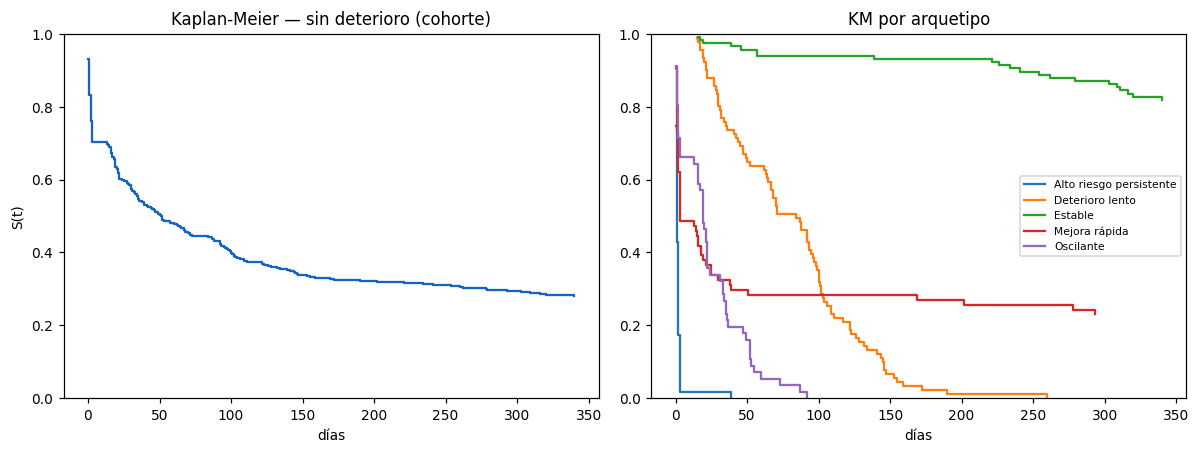

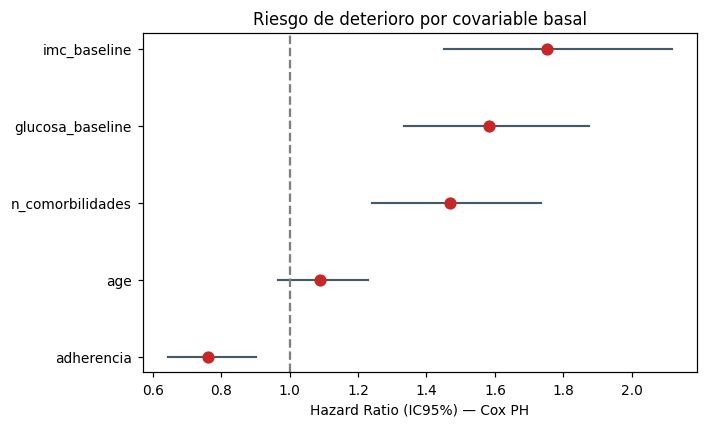

In [3]:
show(FIG/'earlywarning'/'kaplan_meier.png')
show(FIG/'earlywarning'/'cox_forest.png')

## Pacientes con mayor riesgo de deterioro a corto plazo

In [4]:
pd.read_csv(MET/'trend_deterioration_risk.csv').head(10)

,patient_id,archetype,ces,riesgo_slope_m,glucosa_slope_m,deterioration_risk
0,101,Deterioro lento,10.0,0.098,15.743,96.2
1,213,Deterioro lento,5.7,0.094,13.456,95.9
2,227,Deterioro lento,14.6,0.098,16.953,94.8
3,374,Deterioro lento,17.3,0.105,16.570,94.8
4,94,Deterioro lento,11.7,0.095,15.711,94.5
5,372,Deterioro lento,3.2,0.088,9.828,93.7
6,44,Deterioro lento,6.0,0.086,16.664,92.6
7,45,Deterioro lento,10.6,0.087,10.733,91.6
8,315,Deterioro lento,4.9,0.082,13.054,91.3
9,334,Deterioro lento,14.8,0.089,16.486,91.2


### Conclusión 3E
El Cox confirma que **IMC, glucosa y comorbilidades basales** elevan el hazard de deterioro (HR>1) y la **adherencia lo protege** (HR<1). El sistema alerta antes de que aparezca el problema severo.